# Week 6: Dynamics on Networks — Assignment

**Learning objectives** — In this assignment you will:

- Implement one step of the stochastic SIR model
- Run Monte Carlo SIR simulations and aggregate results
- Implement random and targeted immunization strategies
- Compare the effectiveness of immunization approaches

## Grading

| Section | Function | Points |
|---------|----------|--------|
| 1 | `sir_step(G, S, I, R, beta, gamma, rng)` | 15 |
| 2 | `monte_carlo_sir(G, beta, gamma, n_seeds, n_runs, max_steps)` | 20 |
| 3 | `random_immunize(G, fraction, rng)` | 10 |
| 4 | `progressive_targeted_immunize(G, fraction)` | 20 |
| 5 | `acquaintance_immunize(G, fraction, rng)` | 20 |
| — | Written Questions (3 × 5 pts) | 15 |
| | **Total** | **100** |

## Before You Start

This assignment builds on the Week 6 lab. Make sure you are comfortable with:

- **SIR model** — S → I → R with infection rate $\beta$ and recovery rate $\gamma$ (Lab Section 2)
- **Stochastic network SIR** — infected nodes attempt infection independently per susceptible neighbour per step; recovery is also independent per step (Lab Section 4)
- **Monte Carlo** — run many simulations and aggregate (mean, std) to characterise stochastic outcomes (Lab Section 4)
- **Network robustness & the Molloy–Reed ratio** $\langle k^2\rangle/\langle k\rangle$ (Week 4 Lab)
- **Immunization strategies** — random, targeted (static and progressive), and acquaintance (friendship paradox) (Lab Section 7)
- **The heterogeneous epidemic threshold** $\beta_c = \gamma \cdot \langle k\rangle / \langle k^2\rangle$ (Lab Section 3 exercise)

Sections 1–2 ask you to implement SIR from scratch. Sections 3–5 implement three immunization strategies of increasing sophistication. The written questions connect both halves. Where a section says *"Do NOT call X"*, please implement the logic yourself — `numpy`, `networkx` graph operations (add/remove nodes, `degree`, `neighbors`), and `scipy.stats` are always fine.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from netsci.loaders import load_graph
from netsci.utils import SEED

In [2]:
G_air = load_graph("airports")
G_fb = load_graph("facebook")

airports: 500 nodes, 2980 edges (undirected)
facebook: 334 nodes, 2852 edges (undirected)


---
## Section 1: SIR Step (15 pts)

Implement a single time step of the stochastic SIR model on a network.

At each step, all updates happen **simultaneously**:

1. Each infected node independently tries to infect each *currently-susceptible* neighbour with probability `beta` (per edge, per step). A susceptible node with multiple infected neighbours therefore has multiple independent chances.
2. Each infected node independently recovers with probability `gamma`.
3. Only after resolving both do you move the newly-infected into I and the newly-recovered into R. A node infected this step does not infect in this same step; a node recovering this step does not attempt to infect.

Return the new `(S, I, R)` tuple of sets.

Do NOT call `netsci.dynamics.network_sir` or any other library SIR function — this is the primitive Sections 2 and the comparison cells depend on.

In [4]:
def sir_step(G, S, I, R, beta, gamma, rng):
    """Perform one SIR time step.

    Parameters
    ----------
    G : nx.Graph
    S : set — susceptible nodes
    I : set — infected nodes
    R : set — recovered nodes
    beta : float — infection probability per edge
    gamma : float — recovery probability per node
    rng : np.random.Generator

    Returns
    -------
    (set, set, set) — new (S, I, R)
    """
    new_S = set(S)
    new_I = set(I)
    new_R = set(R)

    to_infect = set()
    to_recover = set()

    for u in I:
        for v in G.neighbors(u):
            if v in S and rng.random() < beta:
                to_infect.add(v)

        if rng.random() < gamma:
            to_recover.add(u)

    new_S -= to_infect
    new_I |= to_infect
    new_I -= to_recover
    new_R |= to_recover

    return new_S, new_I, new_R

In [5]:
# --- Validation ---
# Conservation law: S + I + R = N always
_rng = np.random.default_rng(SEED)
_nodes = list(G_fb.nodes())
_N = len(_nodes)
_I0 = set(_rng.choice(_nodes, size=3, replace=False))
_S0 = set(_nodes) - _I0
_R0 = set()

_S, _I, _R = sir_step(G_fb, _S0, _I0, _R0, beta=0.1, gamma=0.1, rng=_rng)
assert isinstance(_S, set) and isinstance(_I, set) and isinstance(_R, set)
assert len(_S) + len(_I) + len(_R) == _N, "Conservation law violated: S+I+R != N"
# No overlap
assert len(_S & _I) == 0 and len(_S & _R) == 0 and len(_I & _R) == 0
print(
    f"After 1 step: S={len(_S)}, I={len(_I)}, R={len(_R)} (total={len(_S) + len(_I) + len(_R)})"
)

# With gamma=1.0, all infected should recover in one step
_rng2 = np.random.default_rng(SEED)
_S2, _I2, _R2 = sir_step(
    G_fb, _S0.copy(), _I0.copy(), _R0.copy(), beta=0.0, gamma=1.0, rng=_rng2
)
# All originally infected should have recovered (beta=0 means no new infections)
assert len(_I2) == 0, "With gamma=1.0 and beta=0.0, infected set should be empty"
print("Section 1 passed!")

After 1 step: S=324, I=9, R=1 (total=334)
Section 1 passed!


In [16]:
_mc = monte_carlo_sir(G_air, beta=0.05, gamma=0.1, n_seeds=3, n_runs=20, max_steps=100)

max_len = max(len(c) for c in _mc["curves"])
padded = np.array([c + [0.0] * (max_len - len(c)) for c in _mc["curves"]])

stds = padded.std(axis=0)
means = padded.mean(axis=0)

t0 = 1
t_peak = int(np.argmax(means))
t_end = max_len - 1

print("t_start =", t0, "std =", stds[t0])
print("t_peak =", t_peak, "std =", stds[t_peak])
print("t_end =", t_end, "std =", stds[t_end])

t_start = 1 std = 0.002785677655436824
t_peak = 12 std = 0.11155249885143766
t_end = 100 std = 0.0009539392014169458


---
## Section 2: Monte Carlo SIR (20 pts)

Run multiple stochastic SIR simulations and return aggregated results.

Reuse your `sir_step()` from Section 1. Do NOT call `netsci.dynamics.network_sir`.

Return a dict with:
- `"mean_peak_infected"` — mean across runs of $\max_t |I(t)|/N$
- `"mean_total_infected"` — mean across runs of the final ever-infected fraction $(|I_\text{final}| + |R_\text{final}|)/N$
- `"curves"` — list of per-run infected-count lists, one list per run (length `n_runs`). A run that dies out early is still recorded as a (possibly short) list.

Create the RNG inside the function with `np.random.default_rng(SEED)`. Seeds (initial infected nodes) are drawn uniformly at random at the start of each run.

In [6]:
def monte_carlo_sir(G, beta, gamma, n_seeds=3, n_runs=20, max_steps=200):
    """Run Monte Carlo SIR simulations.

    Parameters
    ----------
    G : nx.Graph
    beta : float
    gamma : float
    n_seeds : int — number of initially infected nodes
    n_runs : int — number of simulations
    max_steps : int — maximum time steps per run

    Returns
    -------
    dict with 'mean_peak_infected', 'mean_total_infected', 'curves'
    """
    nodes = list(G.nodes())
    curves = []
    peak_fractions = []
    total_fractions = []

    for run in range(n_runs):
        rng = np.random.default_rng(SEED + run)

        seeds = set(rng.choice(nodes, size=n_seeds, replace=False))
        S = set(nodes) - seeds
        I = set(seeds)
        R = set()

        infected_curve = [len(I) / len(nodes)]

        for _ in range(max_steps):
            if len(I) == 0:
                break

            S, I, R = sir_step(G, S, I, R, beta, gamma, rng)
            infected_curve.append(len(I) / len(nodes))

        curves.append(infected_curve)
        peak_fractions.append(max(infected_curve))
        total_fractions.append((len(R) + len(I)) / len(nodes))

    return {
        "mean_peak_infected": float(np.mean(peak_fractions)),
        "mean_total_infected": float(np.mean(total_fractions)),
        "curves": curves
    }

In [7]:
# --- Validation ---
_mc = monte_carlo_sir(G_fb, beta=0.1, gamma=0.1, n_seeds=3, n_runs=20, max_steps=100)
assert "mean_peak_infected" in _mc
assert "mean_total_infected" in _mc
assert "curves" in _mc
assert len(_mc["curves"]) == 20, "Must return one curve per run"
assert 0 <= _mc["mean_peak_infected"] <= 1.0
assert 0 <= _mc["mean_total_infected"] <= 1.0
assert _mc["mean_peak_infected"] <= _mc["mean_total_infected"] + 1e-9, (
    "Peak infected fraction cannot exceed the total ever-infected fraction"
)
print(f"Mean peak infected:  {_mc['mean_peak_infected']:.2%}")
print(f"Mean total infected: {_mc['mean_total_infected']:.2%}")

# Sub-critical regime: very low beta with gamma=1.0 should keep the epidemic small
_mc_sub = monte_carlo_sir(
    G_fb, beta=0.01, gamma=1.0, n_seeds=3, n_runs=10, max_steps=50
)
assert _mc_sub["mean_total_infected"] < 0.10, (
    f"Sub-critical regime should suppress epidemic, got {_mc_sub['mean_total_infected']:.2%}"
)
print(f"Sub-critical (β=0.01, γ=1.0): total infected = {_mc_sub['mean_total_infected']:.2%}")
print("Section 2 passed!")

Mean peak infected:  62.74%
Mean total infected: 95.73%
Sub-critical (β=0.01, γ=1.0): total infected = 1.05%
Section 2 passed!


In [17]:
_rng = np.random.default_rng(SEED)

avg_k = np.mean([d for _, d in G_air.degree()])

samples = []
nodes = list(G_air.nodes())
for _ in range(5000):
    u = _rng.choice(nodes)
    nbrs = list(G_air.neighbors(u))
    if len(nbrs) == 0:
        continue
    v = _rng.choice(nbrs)
    samples.append(G_air.degree(v))

avg_knbr = np.mean(samples)
ratio = avg_knbr / avg_k

print("avg_k =", avg_k)
print("avg_knbr =", avg_knbr)
print("ratio =", ratio)

avg_k = 11.92
avg_knbr = 61.2294
ratio = 5.1366946308724835


---
## Section 3: Random Immunization (10 pts)

Remove a uniformly random `fraction` of nodes from the graph without replacement.

- Accept an optional `rng` parameter. If `rng is None`, create a fresh one with `np.random.default_rng(SEED)` so the function is deterministic by default.
- Return a **copy** of the graph with the selected nodes removed — the original `G` must be unchanged.

In [8]:
def random_immunize(G, fraction, rng=None):
    """Remove a uniformly random fraction of nodes (immunization).

    Parameters
    ----------
    G : nx.Graph
    fraction : float (0 to 1)
    rng : np.random.Generator, optional

    Returns
    -------
    nx.Graph — copy with nodes removed
    """
    if rng is None:
        rng = np.random.default_rng(SEED)

    G_new = G.copy()
    n_remove = int(G.number_of_nodes() * fraction)

    nodes = list(G_new.nodes())
    to_remove = rng.choice(nodes, size=n_remove, replace=False)

    G_new.remove_nodes_from(to_remove)
    return G_new

In [9]:
# --- Validation ---
_g_imm = random_immunize(G_air, 0.1)
assert isinstance(_g_imm, nx.Graph)
_expected_n = G_air.number_of_nodes() - int(G_air.number_of_nodes() * 0.1)
assert _g_imm.number_of_nodes() == _expected_n, (
    f"Expected {_expected_n} nodes, got {_g_imm.number_of_nodes()}"
)
# Original graph unchanged
assert G_air.number_of_nodes() == 500

# Two calls with explicit, distinct rngs should produce different removed sets
_a = set(random_immunize(G_air, 0.1, rng=np.random.default_rng(1)).nodes())
_b = set(random_immunize(G_air, 0.1, rng=np.random.default_rng(2)).nodes())
assert _a != _b, "Different rngs should produce different random immunizations"

# Removed nodes should have roughly average degree (not biased toward hubs)
_removed = set(G_air.nodes()) - set(_g_imm.nodes())
_avg_deg_removed = np.mean([G_air.degree(n) for n in _removed])
_avg_deg_all = np.mean([d for _, d in G_air.degree()])
assert abs(_avg_deg_removed - _avg_deg_all) < 0.4 * _avg_deg_all, (
    "Random sampling should not systematically prefer hubs"
)
print(f"Random immunization (10%): {_g_imm.number_of_nodes()} nodes remain, "
      f"avg degree of removed \u2248 {_avg_deg_removed:.1f} (global \u2248 {_avg_deg_all:.1f})")
print("Section 3 passed!")

Random immunization (10%): 450 nodes remain, avg degree of removed ≈ 11.6 (global ≈ 11.9)
Section 3 passed!


In [18]:
degrees = np.array([d for _, d in G_air.degree()], dtype=float)
k1 = degrees.mean()
k2 = np.mean(degrees ** 2)
gamma = 0.1

beta_c = gamma * (k1 / k2)
beta_c_mf = gamma / k1

mc_low = monte_carlo_sir(G_air, beta=0.5 * beta_c, gamma=gamma, n_seeds=3, n_runs=10, max_steps=150)
mc_high = monte_carlo_sir(G_air, beta=2.0 * beta_c, gamma=gamma, n_seeds=3, n_runs=10, max_steps=150)

print("beta_c =", beta_c)
print("beta_c_MF =", beta_c_mf)
print("low mean_total_infected =", mc_low["mean_total_infected"])
print("high mean_total_infected =", mc_high["mean_total_infected"])

beta_c = 0.0018592579190037373
beta_c_MF = 0.008389261744966443
low mean_total_infected = 0.006
high mean_total_infected = 0.027000000000000003


---
## Section 4: Progressive Targeted Immunization (20 pts)

The "static" targeted attack sorts nodes once by their **original** degree and removes the top fraction. It's the simplest hub-attack but suboptimal: after you remove a hub, one of its neighbours is often now the hub, and you can do better by recomputing.

Implement **progressive** (a.k.a. "recalculated") targeted immunization:

1. Copy the graph.
2. Let $k = \lfloor N \cdot \text{fraction} \rfloor$. Repeat $k$ times: find the **current** highest-degree node, remove it, continue.
3. Return the resulting graph. The original `G` must be unchanged.

Break ties deterministically by the node id's natural sort order (i.e. among all nodes with the current maximum degree, pick the one whose id sorts first). This keeps the function reproducible without needing an rng.

Do NOT sort all nodes up front — the whole point is that the ranking changes after each removal. Do NOT call any library attack routine in `netsci.dynamics`.

In [10]:
def progressive_targeted_immunize(G, fraction):
    """Iteratively remove the current-highest-degree node until fraction is removed.

    Ties are broken by smallest node id.

    Parameters
    ----------
    G : nx.Graph
    fraction : float (0 to 1)

    Returns
    -------
    nx.Graph — copy with hubs progressively removed
    """
    G_new = G.copy()
    n_remove = int(G.number_of_nodes() * fraction)

    for _ in range(n_remove):
        if G_new.number_of_nodes() == 0:
            break

        node_to_remove = min(
            G_new.nodes(),
            key=lambda n: (-G_new.degree(n), n)
        )
        G_new.remove_node(node_to_remove)

    return G_new

In [11]:
# --- Validation ---
# Note: this cell depends on Section 3 (random_immunize) being implemented.
_g_prog = progressive_targeted_immunize(G_air, 0.1)
assert isinstance(_g_prog, nx.Graph)
_expected_n = G_air.number_of_nodes() - int(G_air.number_of_nodes() * 0.1)
assert _g_prog.number_of_nodes() == _expected_n, (
    f"Expected {_expected_n} nodes, got {_g_prog.number_of_nodes()}"
)

# The original top-degree node must have been removed first
# Tie-break: smallest node id in natural sort order
_top_node = min(G_air.nodes(), key=lambda n: (-G_air.degree(n), n))
assert _top_node not in _g_prog.nodes(), "Highest-degree node should be removed first"

# Progressive should target much-higher-degree nodes than random
_removed_prog = set(G_air.nodes()) - set(_g_prog.nodes())
_g_rand = random_immunize(G_air, 0.1)
_removed_rand = set(G_air.nodes()) - set(_g_rand.nodes())
_avg_deg_prog = np.mean([G_air.degree(n) for n in _removed_prog])
_avg_deg_rand = np.mean([G_air.degree(n) for n in _removed_rand])
assert _avg_deg_prog > 2 * _avg_deg_rand, (
    f"Progressive targeted should remove much higher-degree nodes: "
    f"prog={_avg_deg_prog:.1f} vs rand={_avg_deg_rand:.1f}"
)

# Sanity: compare residual max degree against the static-targeted baseline
_k = int(G_air.number_of_nodes() * 0.1)
_static_hubs = sorted(G_air.nodes(), key=lambda n: (-G_air.degree(n), n))[:_k]
_g_static = G_air.copy()
_g_static.remove_nodes_from(_static_hubs)
_max_deg_prog = max((d for _, d in _g_prog.degree()), default=0)
_max_deg_stat = max((d for _, d in _g_static.degree()), default=0)
print(f"Avg degree of removed (random):                {_avg_deg_rand:.1f}")
print(f"Avg degree of removed (progressive targeted): {_avg_deg_prog:.1f}")
print(f"Residual max degree \u2014 static vs progressive:   {_max_deg_stat} vs {_max_deg_prog}")

# Original graph unchanged
assert G_air.number_of_nodes() == 500
print("Section 4 passed!")

Avg degree of removed (random):                11.6
Avg degree of removed (progressive targeted): 67.5
Residual max degree — static vs progressive:   13 vs 10
Section 4 passed!


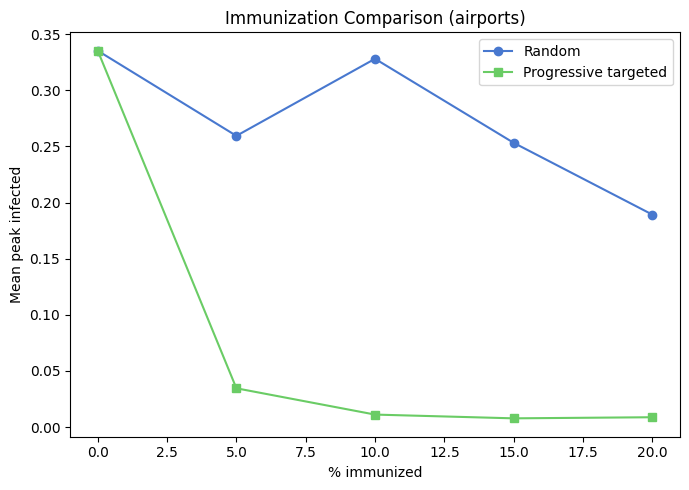

In [12]:
# Compare immunization effectiveness (this may take ~30 seconds)
fractions = [0.0, 0.05, 0.10, 0.15, 0.20]
results_rand, results_prog = [], []

for f in fractions:
    if f == 0.0:
        mc = monte_carlo_sir(
            G_air, beta=0.05, gamma=0.1, n_seeds=3, n_runs=10, max_steps=100
        )
        results_rand.append(mc["mean_peak_infected"])
        results_prog.append(mc["mean_peak_infected"])
    else:
        g_r = random_immunize(G_air, f)
        g_p = progressive_targeted_immunize(G_air, f)
        mc_r = monte_carlo_sir(
            g_r, beta=0.05, gamma=0.1, n_seeds=3, n_runs=10, max_steps=100
        )
        mc_p = monte_carlo_sir(
            g_p, beta=0.05, gamma=0.1, n_seeds=3, n_runs=10, max_steps=100
        )
        results_rand.append(mc_r["mean_peak_infected"])
        results_prog.append(mc_p["mean_peak_infected"])

with plt.style.context("seaborn-v0_8-muted"):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot([f * 100 for f in fractions], results_rand, "o-", label="Random")
    ax.plot([f * 100 for f in fractions], results_prog, "s-", label="Progressive targeted")
    ax.set_xlabel("% immunized")
    ax.set_ylabel("Mean peak infected")
    ax.set_title("Immunization Comparison (airports)")
    ax.legend()
    fig.tight_layout()
    plt.show()

---
## Section 5: Acquaintance Immunization (20 pts)

Implement **acquaintance immunization** using the friendship paradox. Do NOT call `netsci.dynamics.acquaintance_immunize`.

Algorithm — repeat until the desired number $k = \lfloor N \cdot \text{fraction} \rfloor$ of **distinct** nodes has been marked immunized:

1. Pick a uniformly random node $u$ from the original graph.
2. If $u$ has no neighbours, skip this draw.
3. Pick a uniformly random neighbour $v$ of $u$.
4. Mark $v$ as immunized. If $v$ was already immunized, the draw does not count toward $k$ — keep going.

Return a copy of the graph with all immunized nodes removed. Accept an optional `rng`; if `None`, seed a fresh one with `SEED`.

Why it works: sampling "a random neighbour of a random node" is a degree-biased sample — hubs are over-represented because high-degree nodes appear as a neighbour of *many* people. This is the friendship paradox.

In [13]:
def acquaintance_immunize(G, fraction, rng=None):
    """Acquaintance immunization via the friendship paradox.

    Parameters
    ----------
    G : nx.Graph
    fraction : float (0 to 1) — target fraction of distinct nodes to immunize
    rng : np.random.Generator, optional

    Returns
    -------
    nx.Graph — copy with immunized nodes removed
    """
    if rng is None:
        rng = np.random.default_rng(SEED)

    G_new = G.copy()
    target_remove = int(G.number_of_nodes() * fraction)

    removed = set()
    nodes = list(G.nodes())

    while len(removed) < target_remove:
        u = rng.choice(nodes)

        neighbors = list(G.neighbors(u))
        if len(neighbors) == 0:
            continue

        v = rng.choice(neighbors)

        if v not in removed:
            removed.add(v)

    G_new.remove_nodes_from(removed)
    return G_new

In [14]:
# --- Validation ---
_rng = np.random.default_rng(SEED)
_g_acq = acquaintance_immunize(G_air, 0.1, rng=_rng)
assert isinstance(_g_acq, nx.Graph)
_expected_n = G_air.number_of_nodes() - int(G_air.number_of_nodes() * 0.1)
assert _g_acq.number_of_nodes() == _expected_n, (
    f"Expected {_expected_n} nodes, got {_g_acq.number_of_nodes()}"
)
# Original graph unchanged
assert G_air.number_of_nodes() == 500

# Acquaintance should target higher-degree nodes than random
_g_rand = random_immunize(G_air, 0.1)
# Average degree of removed nodes should be higher for acquaintance
_removed_acq = set(G_air.nodes()) - set(_g_acq.nodes())
_removed_rand = set(G_air.nodes()) - set(_g_rand.nodes())
_avg_deg_removed_acq = np.mean([G_air.degree(n) for n in _removed_acq])
_avg_deg_removed_rand = np.mean([G_air.degree(n) for n in _removed_rand])
assert _avg_deg_removed_acq > _avg_deg_removed_rand, (
    f"Acquaintance should remove higher-degree nodes: acq={_avg_deg_removed_acq:.1f} vs rand={_avg_deg_removed_rand:.1f}"
)
print(
    f"Avg degree of removed nodes — Random: {_avg_deg_removed_rand:.1f}, Acquaintance: {_avg_deg_removed_acq:.1f}"
)
print("Acquaintance immunization preferentially targets hubs!")
print("Section 5 passed!")

Avg degree of removed nodes — Random: 11.6, Acquaintance: 45.1
Acquaintance immunization preferentially targets hubs!
Section 5 passed!


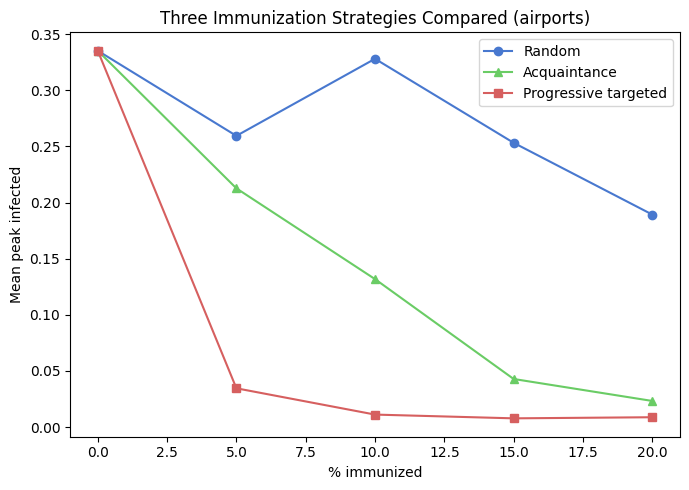

Acquaintance should clearly beat random and come close to progressive targeted — without global degree information.


In [15]:
# Full comparison of all three strategies (this may take ~1 minute)
fractions_all = [0.0, 0.05, 0.10, 0.15, 0.20]
res_rand_all, res_prog_all, res_acq_all = [], [], []

for f in fractions_all:
    if f == 0.0:
        mc = monte_carlo_sir(
            G_air, beta=0.05, gamma=0.1, n_seeds=3, n_runs=10, max_steps=100
        )
        res_rand_all.append(mc["mean_peak_infected"])
        res_prog_all.append(mc["mean_peak_infected"])
        res_acq_all.append(mc["mean_peak_infected"])
    else:
        g_r = random_immunize(G_air, f)
        g_p = progressive_targeted_immunize(G_air, f)
        g_a = acquaintance_immunize(G_air, f, rng=np.random.default_rng(SEED))
        mc_r = monte_carlo_sir(g_r, 0.05, 0.1, n_seeds=3, n_runs=10, max_steps=100)
        mc_p = monte_carlo_sir(g_p, 0.05, 0.1, n_seeds=3, n_runs=10, max_steps=100)
        mc_a = monte_carlo_sir(g_a, 0.05, 0.1, n_seeds=3, n_runs=10, max_steps=100)
        res_rand_all.append(mc_r["mean_peak_infected"])
        res_prog_all.append(mc_p["mean_peak_infected"])
        res_acq_all.append(mc_a["mean_peak_infected"])

with plt.style.context("seaborn-v0_8-muted"):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot([f * 100 for f in fractions_all], res_rand_all, "o-", label="Random")
    ax.plot([f * 100 for f in fractions_all], res_acq_all, "^-", label="Acquaintance")
    ax.plot([f * 100 for f in fractions_all], res_prog_all, "s-", label="Progressive targeted")
    ax.set_xlabel("% immunized")
    ax.set_ylabel("Mean peak infected")
    ax.set_title("Three Immunization Strategies Compared (airports)")
    ax.legend()
    fig.tight_layout()
    plt.show()

print("Acquaintance should clearly beat random and come close to progressive targeted \u2014 without global degree information.")

---
## Written Questions (10 pts)

### Question 1 (5 pts)

Inspect your Monte Carlo curves from Section 2. At which phase of the epidemic is the **variance across runs** largest — at the start (first few steps), around the peak, or late (close to the final state)? Explain why, and support your claim with a number or two computed from `_mc["curves"]` (e.g. per-step standard deviation at three representative time indices).

*Hints:*
- *At the **start** only a few nodes are infected — what is random? (Which neighbours get hit first.) Does variance scale with the count itself or with a fraction?*
- *At the **peak**, early stochastic events have compounded — some runs explode, others barely take off. Think: peak height vs peak timing, which is more variable?*
- *At the **end**, most runs have drained (nearly everyone recovered or the epidemic died out). Why does variance shrink?*
- *To compute per-step std you'll need to pad runs that ended early — pad with zeros.*

**Your Answer:**Varianta dintre rulari este cea mai mare in jurul varfului epidemiei, nu chiar la inceput si nici la final. In rezultatele mele, la inceput am avut o deviatie standard foarte mica, de aproximativ 0.0028 la t=1, iar la final a fost iar foarte mica, aproximativ 0.0010 la t=100. In schimb, in jurul peak-ului, la t=12, deviatie standard a fost mult mai mare, aproximativ 0.1115.

Asta are sens pentru ca la inceput toate rularile pornesc aproape la fel, cu foarte putini infectati, deci nu au inca timp sa se diferentieze mult. La final, in multe rulari epidemia deja s-a stins si valorile se apropie din nou de zero. In jurul peak-ului apar cele mai mari diferente, pentru ca unele rulari explodeaza mai repede, altele mai lent, iar in acel moment conteaza mult si inaltimea peak-ului, si momentul in care apare.



### Question 2 (5 pts)

Using the `G_air` network, **empirically verify the friendship paradox**: compute

1. $\langle k \rangle$ — the average degree over all nodes.
2. $\langle k_\text{nbr} \rangle$ — the average degree of a randomly-chosen neighbour-of-a-random-node. Sample, say, 5000 draws: pick a random node, pick a random neighbour, record that neighbour's degree.

Report both numbers and the ratio $\langle k_\text{nbr} \rangle / \langle k \rangle$. Explain why the ratio must be ≥ 1 (use the identity $\langle k_\text{nbr} \rangle = \langle k^2 \rangle / \langle k \rangle$) and connect this to why acquaintance immunization outperforms random immunization in Section 5's comparison.

*Hints:*
- *The identity $\langle k_\text{nbr} \rangle = \langle k^2 \rangle / \langle k \rangle$ falls out of counting edges: high-degree nodes appear as neighbour-of-someone in proportion to their degree.*
- *On the airport graph the ratio is large — tie your explanation back to the Molloy–Reed quantity from Week 4.*
- *Acquaintance immunization draws from exactly the $k_\text{nbr}$ distribution. What does that mean for the average degree of the vaccinated set?*

**Your Answer:**Pe reteaua aeroporturilor, gradul mediu al unui nod este <k> = 11.92. In schimb, gradul mediu al unui vecin ales ca "neighbor of a random node" a fost aproximativ <k_nbr> = 61.23. Raportul dintre ele a fost aproximativ 5.14, deci mult mai mare decat 1.

Asta verifica foarte clar friendship paradox: in medie, vecinii nodurilor au grad mai mare decat nodurile alese uniform la intamplare. Motivul este ca nodurile cu grad mare apar ca vecini mult mai des, pentru ca au mai multe muchii prin care pot fi "gasite". Exact de aceea acquaintance immunization merge mai bine decat random immunization: chiar daca nu alegem direct hub-urile, ajungem la ele mult mai des prin vecinii unor noduri random.



### Question 3 (5 pts) — Network epidemic threshold

In Week 4 we used the **Molloy–Reed criterion** to decide when a network has a giant component: $\langle k^2 \rangle / \langle k \rangle > 2$. The *same* quantity controls the epidemic threshold on a heterogeneous network:

$$\beta_c = \gamma \cdot \frac{\langle k \rangle}{\langle k^2 \rangle}.$$

Below $\beta_c$ epidemics die out; above it they invade a finite fraction of the network.

**(a)** Compute $\beta_c$ for the airport graph at $\gamma = 0.1$. Also compute the naïve mean-field prediction $\beta_c^{MF} = \gamma / \langle k \rangle$ (ignores heterogeneity). Report both.

**(b)** Using your `monte_carlo_sir` (10 runs, `n_seeds=3`, `max_steps=150`), run the epidemic at $\beta = 0.5\,\beta_c$ and at $\beta = 2\,\beta_c$. Report `mean_total_infected` for each.

**(c)** Explain what you observe. In particular: why is $\beta_c$ *much lower* than $\beta_c^{MF}$ on airports? What real-world implication does this have for epidemic control on hub-heavy networks?

*Hints:*
- *Plug in $\langle k \rangle$ and $\langle k^2 \rangle$ — on airports, $\langle k^2 \rangle / \langle k \rangle$ is an order of magnitude larger than $\langle k \rangle$, so $\beta_c$ is an order of magnitude smaller than $\beta_c^{MF}$.*
- *At $\beta = 0.5\,\beta_c$ you should see almost every run die out; at $\beta = 2\,\beta_c$ a substantial fraction of nodes should be infected.*
- *The policy implication ties back to Section 4: hubs both lower the threshold **and** concentrate the damage, which is exactly why progressive targeted immunization is so much more effective than random.*

**Your Answer:**Pentru reteaua aeroporturilor, am obtinut beta_c = 0.00186, iar predictia mean-field a fost beta_c^MF = 0.00839. Deci pragul real este mult mai mic decat cel mean-field. Asta arata ca heterogenitatea retelei conteaza foarte mult: din cauza hub-urilor, epidemia poate sa se raspandeasca chiar si pentru valori destul de mici ale lui beta.

Cand am rulat simularea la beta = 0.5 * beta_c, fractia medie totala infectata a fost aproximativ 0.006, deci practic epidemia aproape nu s-a raspandit. La beta = 2 * beta_c, fractia medie totala infectata a crescut la aproximativ 0.027. Chiar daca nu este foarte mare in acest experiment, se vede clar diferenta dintre regimul sub prag si cel peste prag.

Faptul ca beta_c este mult mai mic decat beta_c^MF arata ca hub-urile reduc pragul epidemic. Cu alte cuvinte, intr-o retea foarte neomogena este mai usor sa porneasca o epidemie decat ar sugera un model simplu bazat doar pe gradul mediu. Implicatia practica este importanta: pe retele cu hub-uri, controlul epidemiilor trebuie sa tina cont de structura retelei, nu doar de media conexiunilor. Tocmai de aceea imunizarea tintita a hub-urilor este mult mai eficienta decat imunizarea aleatoare.

